# 딥러닝분석_(1)LSTM주가분석

In [ ]:
# 주가 데이터를 다운로드 받기 위해서 야후 파이낸스 라이브러리 설치
!pip install yfinance

# 1. 데이터 수집

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

### - 기업 주가 데이터를 다운로드하여 데이터프레임으로 저장

In [2]:
name = 'GOOG'  #종목명 -구글

start_day = '2021-01-01'
end_day = '2024-08-01'

In [3]:
stock = yf.download(name, start=start_day, end=end_day)

[*********************100%%**********************]  1 of 1 completed


In [4]:
print(stock.shape)  #작업 확인용 출력
stock.head() #작업 확인용 출력

(899, 6)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-01-04,87.876999,88.032501,85.392502,86.412003,86.313782,38038000
2021-01-05,86.250000,87.383499,85.900749,87.045998,86.947060,22906000
2021-01-06,85.131500,87.400002,84.949997,86.764503,86.665878,52042000
2021-01-07,87.002998,89.419998,86.852501,89.362503,89.260925,45300000
2021-01-08,89.399002,90.491997,88.676750,90.360497,90.257790,41012000


# 2. 데이터 준비 및 탐색

### - 분석할 컬럼(날짜, 종가) 추출

In [5]:
stock2 = pd.DataFrame(stock['Close'])

stock2.head() #작업 확인용 출력

,Close
Date,
2021-01-04,86.412003
2021-01-05,87.045998
2021-01-06,86.764503
2021-01-07,89.362503
2021-01-08,90.360497


#### - 파일 저장

In [6]:
# 다운로드한 주가 데이터를 파일 저장
stock2.to_csv('./14장_data/'+name+'.csv') 

### - 데이터 정규화 

In [7]:
stock2.reset_index()
stock_values = stock2.values

print(stock_values[0]) #작업 확인용 출력

[86.41200256]


### - 0~1 범위로 스케일링

In [8]:
from sklearn.preprocessing import MinMaxScaler

In [9]:
scaler = MinMaxScaler(feature_range=(0,1))
stock_values_scaled=scaler.fit_transform(stock_values)

stock_values_scaled[0] #작업 확인용 출력

array([0.02676564])

# 3. 분석 모델 구축

## 3-1. 주가 분석 모델의 학습용 데이터 준비

In [10]:
n_train = int(len(stock_values)*0.8)  #학습용 데이터 갯수
n_test = len(stock_values) - n_train  #평가용 데이터 갯수

print(n_train, n_test) #작업 확인용 출력

719 180


In [11]:
X_train,Y_train=[],[]

#20일 구간의 주가를 x 값으로하고, 그 다음날 값을 y 값으로 정리하기
for i in range(20, n_train):
  X_train.append(stock_values_scaled[i-20:i,0])
  Y_train.append(stock_values_scaled[i,0])
   
X_train[0] #작업 확인용 출력

array([0.02676564, 0.03257305, 0.02999455, 0.0537923 , 0.06293394,
       0.04438949, 0.03515161, 0.03874694, 0.03223417, 0.03040674,
       0.05544565, 0.0994321 , 0.1014244 , 0.10591279, 0.10515712,
       0.11332785, 0.07373362, 0.08853626, 0.07600077, 0.10605019])

### - LSTM 모델의 입력층의 구조로 변형_reshape()

In [12]:
X_train1, Y_train1 = np.array(X_train), np.array(Y_train)
X_train2 = np.reshape(X_train1, (X_train1.shape[0],X_train1.shape[1],1))

print(X_train2.shape) #작업 확인용 출력 
X_train2[0] #작업 확인용 출력

(699, 20, 1)


array([[0.02676564],
       [0.03257305],
       [0.02999455],
       [0.0537923 ],
       [0.06293394],
       [0.04438949],
       [0.03515161],
       [0.03874694],
       [0.03223417],
       [0.03040674],
       [0.05544565],
       [0.0994321 ],
       [0.1014244 ],
       [0.10591279],
       [0.10515712],
       [0.11332785],
       [0.07373362],
       [0.08853626],
       [0.07600077],
       [0.10605019]])

## 3-2. LSTM 모델 구축

In [13]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

### - LSTM 모델 구성

In [14]:
lstm_stock = Sequential()

lstm_stock.add(LSTM(units=20, return_sequences=True, input_shape=(X_train2.shape[1],1)))
lstm_stock.add(LSTM(units=20, return_sequences=False))
lstm_stock.add(Dense(1))

### - LSTM 모델 학습

In [15]:
#학습 파라미터  설정
lstm_stock.compile(loss='mean_squared_error', optimizer='adam')

#학습 수행
lstm_stock.fit(X_train2, Y_train1, epochs=10, batch_size=1, verbose=2)

Epoch 1/10
699/699 - 3s - loss: 0.0045 - 3s/epoch - 5ms/step
Epoch 2/10
699/699 - 2s - loss: 0.0018 - 2s/epoch - 3ms/step
Epoch 3/10
699/699 - 2s - loss: 0.0014 - 2s/epoch - 3ms/step
Epoch 4/10
699/699 - 2s - loss: 0.0012 - 2s/epoch - 3ms/step
Epoch 5/10
699/699 - 2s - loss: 9.9603e-04 - 2s/epoch - 3ms/step
Epoch 6/10
699/699 - 2s - loss: 9.4943e-04 - 2s/epoch - 3ms/step
Epoch 7/10
699/699 - 2s - loss: 8.5731e-04 - 2s/epoch - 3ms/step
Epoch 8/10
699/699 - 2s - loss: 7.9995e-04 - 2s/epoch - 3ms/step
Epoch 9/10
699/699 - 2s - loss: 6.7093e-04 - 2s/epoch - 3ms/step
Epoch 10/10
699/699 - 2s - loss: 6.2282e-04 - 2s/epoch - 3ms/step


## 3-3. 평가 데이터로 주가 예측

### - 평가용 데이터 만들기

In [16]:
stock_test = stock_values_scaled[n_train-20:]
X_test = []

for i in range(20, len(stock_test)):
  X_test.append(stock_test[i-20:i,0])


X_test[0] #작업 확인용 출력

array([0.50462582, 0.5221215 , 0.52670152, 0.51103781, 0.50828978,
       0.48777141, 0.49839693, 0.5187322 , 0.39552989, 0.36594305,
       0.36557664, 0.38710268, 0.3829807 , 0.40377393, 0.41302557,
       0.42942195, 0.4393148 , 0.44801679, 0.45589442, 0.44151325])

### - LSTM 모델의 입력층의 구조로 변형_reshape()

In [17]:
X_test = np.array(X_test)
X_test = np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))

print(X_test.shape)  #작업 확인용 출력
print(X_test[0])

(180, 20, 1)
[[0.50462582]
 [0.5221215 ]
 [0.52670152]
 [0.51103781]
 [0.50828978]
 [0.48777141]
 [0.49839693]
 [0.5187322 ]
 [0.39552989]
 [0.36594305]
 [0.36557664]
 [0.38710268]
 [0.3829807 ]
 [0.40377393]
 [0.41302557]
 [0.42942195]
 [0.4393148 ]
 [0.44801679]
 [0.45589442]
 [0.44151325]]


### - 모델 예측 수행

In [18]:
predicted_value = lstm_stock.predict(X_test)

predicted_value[0] #작업 확인용 출력

6/6 [==============================] - 0s 2ms/step


array([0.4493838], dtype=float32)

# 4. 결과 분석 및 시각화

##### - 예측값을 스케일링 이전 값(원래 주가)으로 되돌림.

In [19]:
predicted_value = scaler.inverse_transform(predicted_value)

predicted_value[0] #작업 확인용 출력

array([132.54922], dtype=float32)

### - 그래프에 사용할 데이터 리스트 정리하기

In [21]:
stock_train_vis = stock[:n_train]
stock_test_vis = stock[n_train:]
stock_test_vis['Predictions'] = predicted_value

C:\Users\user\AppData\Local\Temp\ipykernel_24464\2531245371.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_test_vis['Predictions'] = predicted_value


In [20]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'GOOG (2021-01-01 ~ 2024-08-01 )')

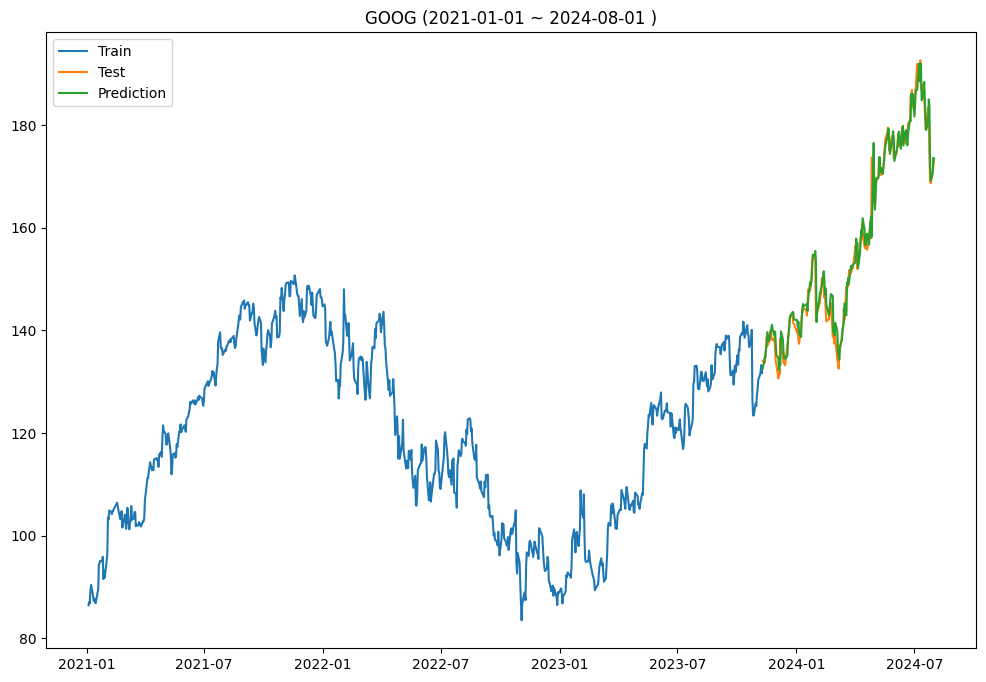

In [22]:
plt.figure(figsize = (12,8))
plt.plot(stock_train_vis['Close'], label = 'Train')
plt.plot(stock_test_vis['Close'], label = 'Test')
plt.plot(stock_test_vis['Predictions'], label = 'Prediction')
plt.legend()
plt.title(name + ' (' + start_day + ' ~ ' + end_day + ' )')